# Down Syndrome Model Selection

### Common Imports

In [46]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import BorderlineSMOTE, SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.calibration import CalibratedClassifierCV

from keras.models import Sequential
from keras.layers import Dense

import tensorflow as tf

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

### Load Data

In [19]:
df = pkl.load(open("../../../data/processed/down_syndrome/cleaned_df.pkl", "rb"))

### Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["target"]),
    df["target"],
    test_size=0.2,
    random_state=14,
    stratify=df["target"],
)

Because our data is highly imbalanced, we'll try using SMOTE to oversample.

In [54]:
sm = SMOTE(random_state=14)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [55]:
bsm = BorderlineSMOTE(random_state=14)
X_train_bsm, y_train_bsm = bsm.fit_resample(X_train, y_train)

### Data Transformation

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["mothers_single_year_age", "fathers_combined_age"])
    ]
)

In [57]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

X_train_sm_prepared = preprocessor.fit_transform(X_train_sm)
X_test_sm_prepared = preprocessor.transform(X_test)

X_train_bsm_prepared = preprocessor.fit_transform(X_train_bsm)
X_test_bsm_prepared = preprocessor.transform(X_test)

### Logistic Regression Model

In [25]:
log_reg = LogisticRegression(random_state=14)

log_reg.fit(X_train_prepared, y_train)

pred_log_reg = log_reg.predict(X_test_prepared)

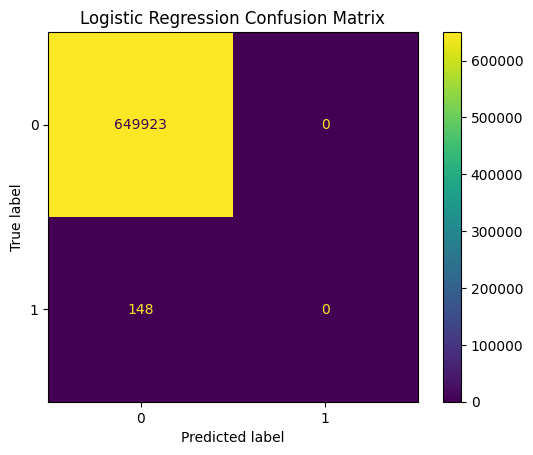

In [26]:
cm_log_reg = confusion_matrix(y_test, pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [27]:
log_reg_sm = LogisticRegression(random_state=14)
log_reg_sm.fit(X_train_sm_prepared, y_train_sm)
pred_log_reg_sm = log_reg_sm.predict(X_test_sm_prepared)

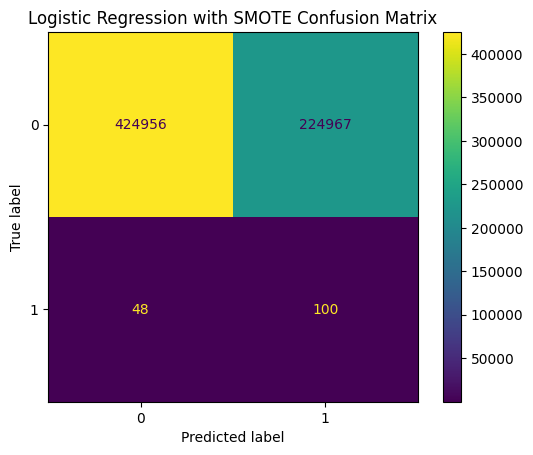

In [28]:
cm_log_reg_sm = confusion_matrix(y_test, pred_log_reg_sm)
disp_log_reg_sm = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg_sm)
disp_log_reg_sm.plot()
plt.title("Logistic Regression with SMOTE Confusion Matrix")
plt.show()

In [29]:
log_reg_bsm = LogisticRegression(random_state=14)
log_reg_bsm.fit(X_train_bsm_prepared, y_train_bsm)
pred_log_reg_bsm = log_reg_bsm.predict(X_test_bsm_prepared)

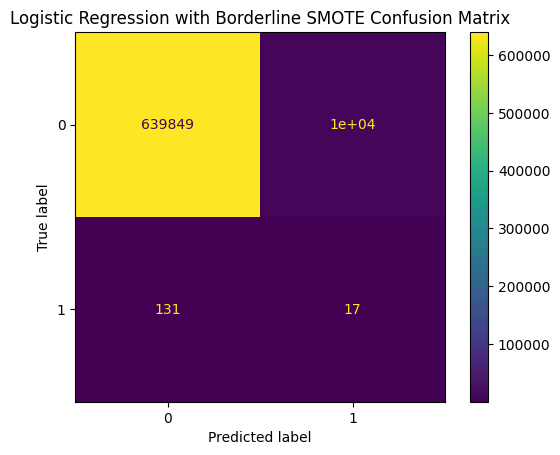

In [30]:
cm_log_reg_bsm = confusion_matrix(y_test, pred_log_reg_bsm)
disp_log_reg_bsm = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg_bsm)
disp_log_reg_bsm.plot()
plt.title("Logistic Regression with Borderline SMOTE Confusion Matrix")
plt.show()

In [32]:
log_reg_f1_score = f1_score(y_test, pred_log_reg)
log_reg_sm_f1_score = f1_score(y_test, pred_log_reg_sm)
log_reg_bsm_f1_score = f1_score(y_test, pred_log_reg_bsm)
print(f"Logistic Regression F1 Score: {log_reg_f1_score:.4f}")
print(f"Logistic Regression with SMOTE F1 Score: {log_reg_sm_f1_score:.4f}")
print(f"Logistic Regression with Borderline SMOTE F1 Score: {log_reg_bsm_f1_score:.4f}")

Logistic Regression F1 Score: 0.0000
Logistic Regression with SMOTE F1 Score: 0.0009
Logistic Regression with Borderline SMOTE F1 Score: 0.0033


### Random Forest Classifier

In [33]:
rfc = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)

rfc.fit(X_train_prepared, y_train)

pred_rfc = rfc.predict(X_test_prepared)

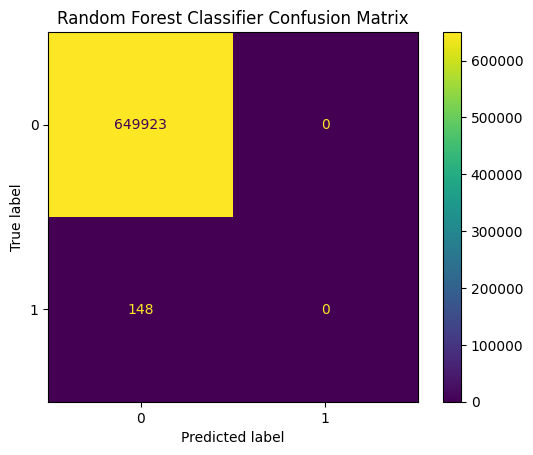

In [34]:
cm_rfc = confusion_matrix(y_test, pred_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc)
disp_rfc.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

In [35]:
rfc_sm = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)
rfc_sm.fit(X_train_sm_prepared, y_train_sm)
pred_rfc_sm = rfc_sm.predict(X_test_sm_prepared)

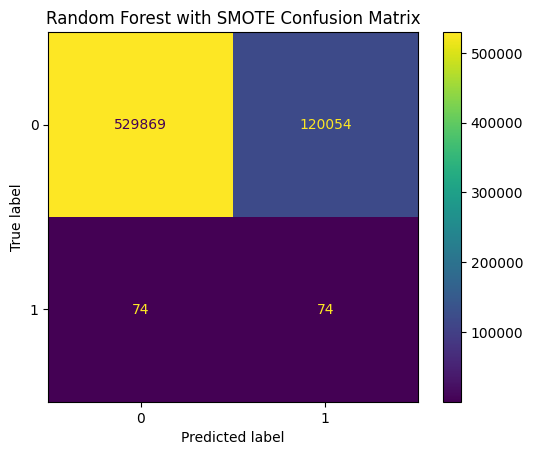

In [36]:
cm_rfc_sm = confusion_matrix(y_test, pred_rfc_sm)
disp_rfc_sm = ConfusionMatrixDisplay(confusion_matrix=cm_rfc_sm)
disp_rfc_sm.plot()
plt.title("Random Forest with SMOTE Confusion Matrix")
plt.show()

In [37]:
rfc_bsm = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)
rfc_bsm.fit(X_train_bsm_prepared, y_train_bsm)
pred_rfc_bsm = rfc_bsm.predict(X_test_bsm_prepared)

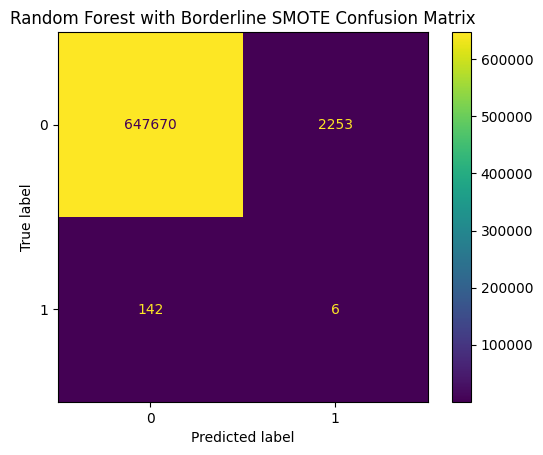

In [38]:
cm_rfc_bsm = confusion_matrix(y_test, pred_rfc_bsm)
disp_rfc_bsm = ConfusionMatrixDisplay(confusion_matrix=cm_rfc_bsm)
disp_rfc_bsm.plot()
plt.title("Random Forest with Borderline SMOTE Confusion Matrix")
plt.show()

In [39]:
rfc_f1_score = f1_score(y_test, pred_rfc)
rfc_sm_f1_score = f1_score(y_test, pred_rfc_sm)
rfc_bsm_f1_score = f1_score(y_test, pred_rfc_bsm)
print(f"Random Forest Classifier F1 Score: {rfc_f1_score:.4f}")
print(f"Random Forest with SMOTE F1 Score: {rfc_sm_f1_score:.4f}")
print(f"Random Forest with Borderline SMOTE F1 Score: {rfc_bsm_f1_score:.4f}")

Random Forest Classifier F1 Score: 0.0000
Random Forest with SMOTE F1 Score: 0.0012
Random Forest with Borderline SMOTE F1 Score: 0.0050


### Neural Network

In [ ]:
nn = Sequential()
nn.add(Dense(16, activation="relu"))
nn.add(Dense(8, activation="relu"))
nn.add(Dense(1, activation="sigmoid"))

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn.fit(
    X_train_prepared,
    y_train,
    epochs=10,
    batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2, restore_best_weights=True, min_delta=0.05, monitor="loss"
        )
    ],
)

nn_preds = (nn.predict(X_test_prepared) > 0.5).astype(int)

Epoch 1/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.9945 - loss: 0.0268
Epoch 2/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9998 - loss: 0.0023
Epoch 3/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9998 - loss: 0.0021
Epoch 4/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9998 - loss: 0.0021
20315/20315 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step


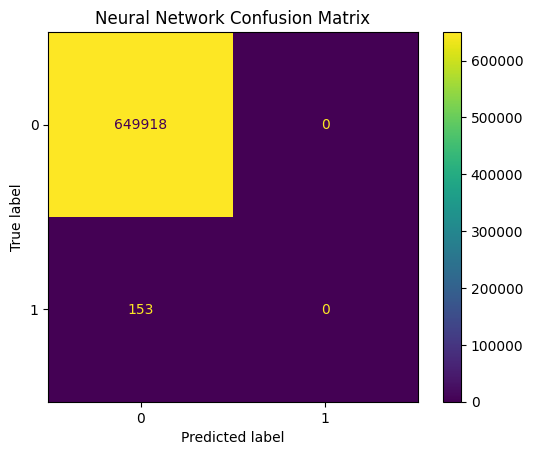

In [59]:
nn_cm = confusion_matrix(y_test, nn_preds)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=nn_cm)
disp_nn.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [ ]:
nn_sm = Sequential()
nn_sm.add(Dense(16, activation="relu"))
nn_sm.add(Dense(8, activation="relu"))
nn_sm.add(Dense(1, activation="sigmoid"))

nn_sm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn_sm.fit(
    X_train_sm_prepared,
    y_train_sm,
    epochs=10,
    batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2, restore_best_weights=True, min_delta=0.05, monitor="loss"
        )
    ],
)

nn_sm_preds = (nn_sm.predict(X_test_sm_prepared) > 0.5).astype(int)

Epoch 1/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6742 - loss: 0.6009
Epoch 2/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.6836 - loss: 0.5946
Epoch 3/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.6883 - loss: 0.5919
Epoch 4/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.6896 - loss: 0.5899
Epoch 5/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.6922 - loss: 0.5874
Epoch 6/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 40s 8ms/step - accuracy: 0.6955 - loss: 0.5852
Epoch 7/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.6971 - loss: 0.5838
Epoch 8/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.6971 - loss: 0.5828
Epoch 9/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.6981 - loss: 0.5816
Epoch 10/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.6988 - loss: 0.5806
20315/20315 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step


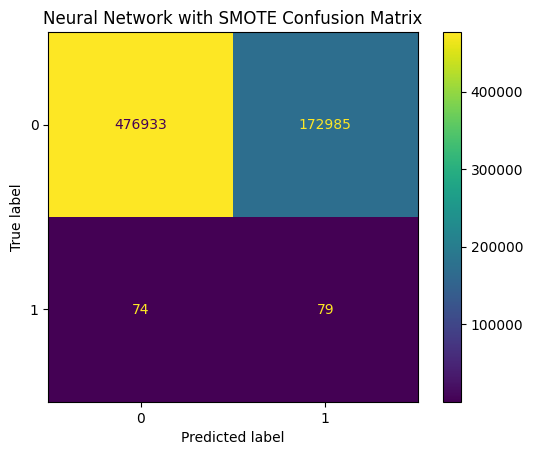

In [61]:
nn_cm_sm = confusion_matrix(y_test, nn_sm_preds)
disp_nn_sm = ConfusionMatrixDisplay(confusion_matrix=nn_cm_sm)
disp_nn_sm.plot()
plt.title("Neural Network with SMOTE Confusion Matrix")
plt.show()

In [62]:
nn_bsm = Sequential()
nn_bsm.add(Dense(16, activation="relu"))
nn_bsm.add(Dense(8, activation="relu"))
nn_bsm.add(Dense(1, activation="sigmoid"))

nn_bsm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn_bsm.fit(
    X_train_bsm_prepared,
    y_train_bsm,
    epochs=10,
    batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2, restore_best_weights=True, min_delta=0.05, monitor="loss"
        )
    ],
)

nn_bsm_preds = (nn_bsm.predict(X_test_bsm_prepared) > 0.5).astype(int)

Epoch 1/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9828 - loss: 0.0745
Epoch 2/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9922 - loss: 0.0343
Epoch 3/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9937 - loss: 0.0283
Epoch 4/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9948 - loss: 0.0249
20315/20315 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step


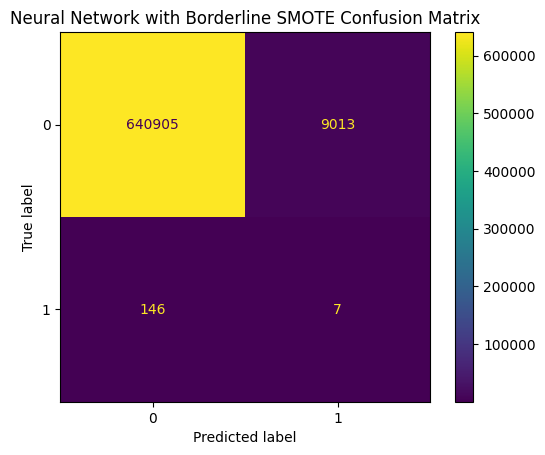

In [63]:
nn_bsm_cm = confusion_matrix(y_test, nn_bsm_preds)
disp_nn_bsm = ConfusionMatrixDisplay(confusion_matrix=nn_bsm_cm)
disp_nn_bsm.plot()
plt.title("Neural Network with Borderline SMOTE Confusion Matrix")
plt.show()

In [64]:
nn_f1_score = f1_score(y_test, nn_bsm_preds)
nn_sm_f1_score = f1_score(y_test, nn_sm_preds)
nn_bsm_f1_score = f1_score(y_test, nn_bsm_preds)
print(f"Neural Network F1 Score: {nn_f1_score:.4f}")
print(f"Neural Network with SMOTE F1 Score: {nn_sm_f1_score:.4f}")
print(f"Neural Network with Borderline SMOTE F1 Score: {nn_bsm_f1_score:.4f}")

Neural Network F1 Score: 0.0015
Neural Network with SMOTE F1 Score: 0.0009
Neural Network with Borderline SMOTE F1 Score: 0.0015


### Conclusion

The best performing model based on F1 score was the Random Forest trained on the Borderline SMOTE data. However, with an F1 score of < 0.1, our model would be considered highly inaccurate.

Though parents' ages are top predictors for Down syndrome, they are not enough for reliable prediction.